In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Task: **01**

In [15]:
df = pd.read_csv("superstore.csv", encoding="latin1")
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


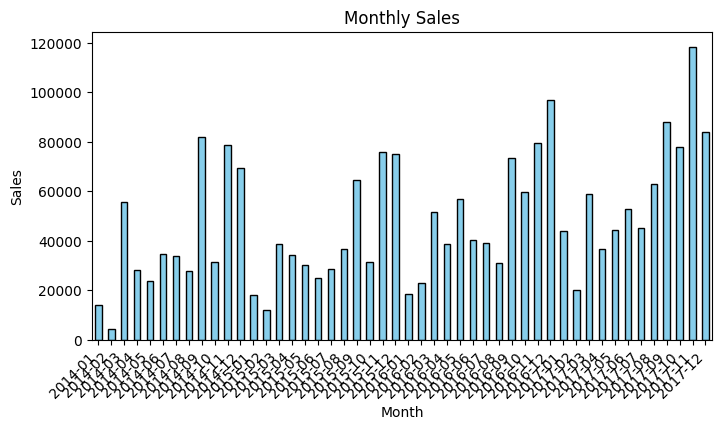

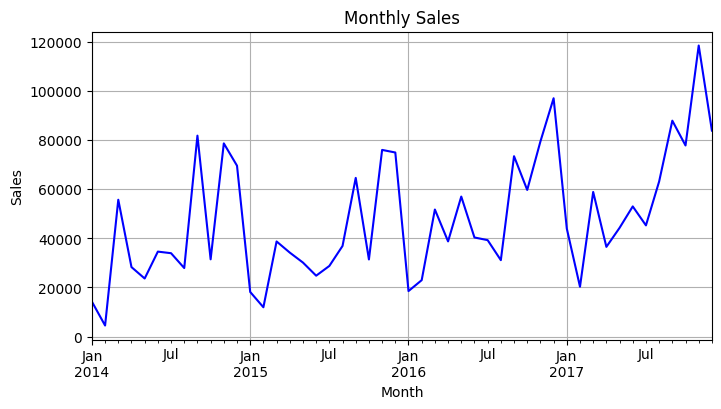

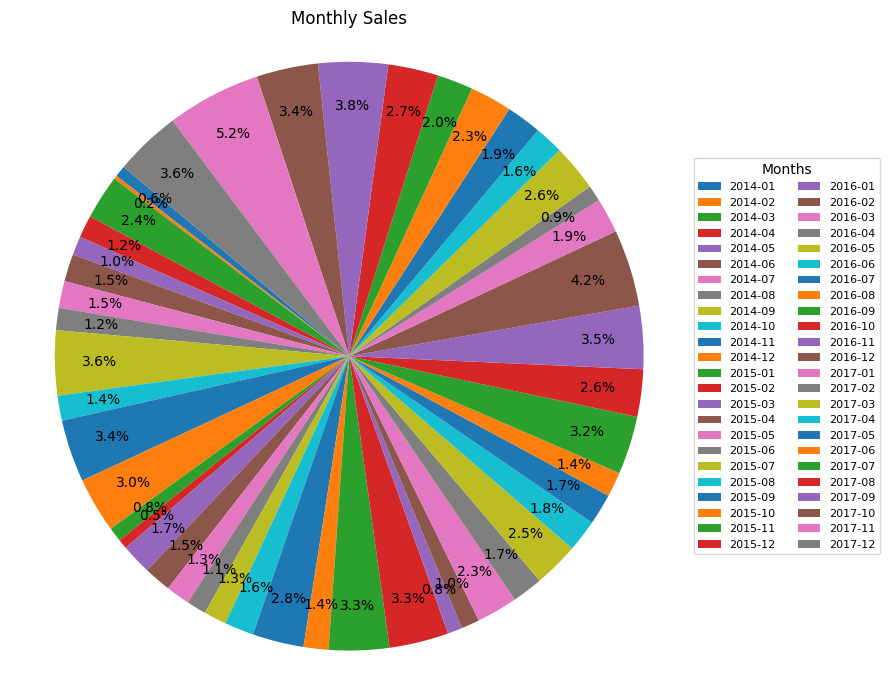

In [89]:
df['Order Date']=pd.to_datetime(df['Order Date'])
monthly=df.resample('ME', on='Order Date')['Sales'].sum()

plt.figure(figsize=(8,4))
monthly.plot(kind='bar',color='skyblue',edgecolor='black')
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(
    ticks=range(len(monthly)),
    labels=monthly.index.strftime('%Y-%m'),
    rotation=45,
    ha='right'
)
plt.show()

plt.figure(figsize=(8,4))
monthly.plot(kind='line',color='blue')
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid()
plt.show()


plt.figure(figsize=(9, 7))
wedges,_, _ = plt.pie(monthly, autopct='%1.1f%%',pctdistance=0.85,startangle=140)
plt.title('Monthly Sales')
plt.axis('equal')

month_labels = monthly.index.strftime('%Y-%m')
plt.legend(
    wedges,
    month_labels,
    title="Months",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=8,
    ncol=2
)

plt.tight_layout()
plt.show()

Line chart is the bet one in this scenario because of the clear trends shown in monthly salary throughout the years and also talking about the worst chart i am gonna say it is definitely pie chart because of ambigous data and no legend and unclear representation due to many partitions.

# **Task: 02**

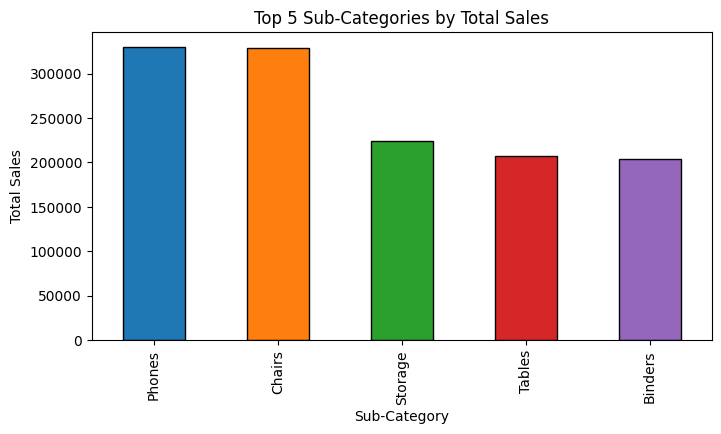

/tmp/ipykernel_791/3293632402.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample('M', on='Order Date')['Sales'].sum()


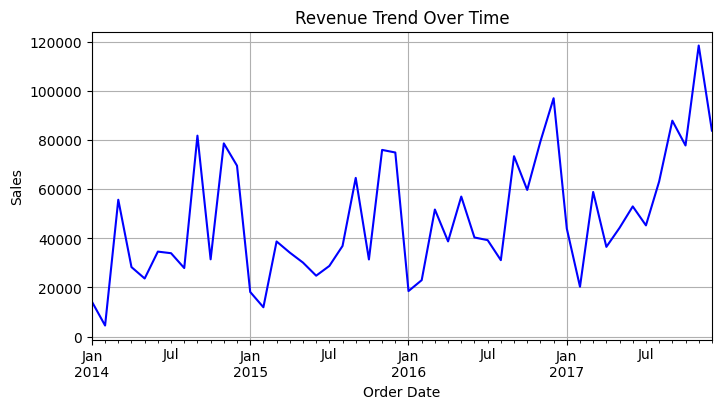

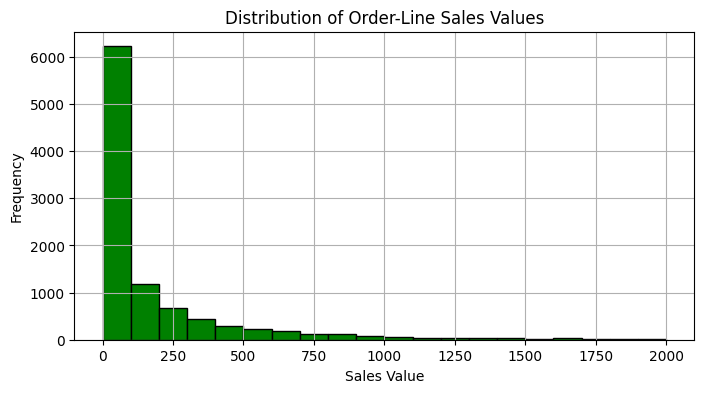

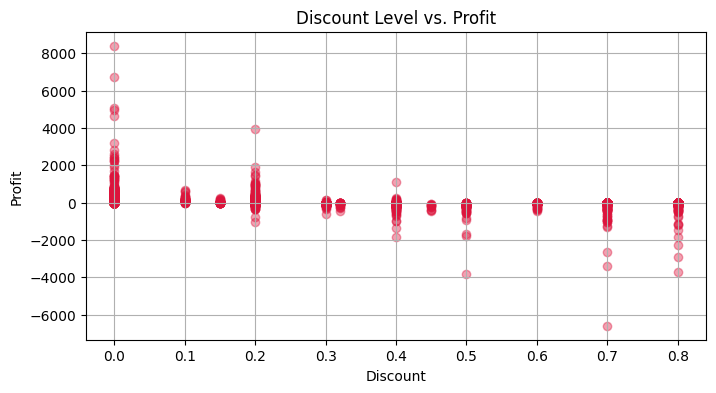

In [88]:
top5 = df.groupby('Sub-Category')['Sales'].sum().nlargest(5)
plt.figure(figsize=(8, 4))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
top5.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Top 5 Sub-Categories by Total Sales')
plt.ylabel('Total Sales')
plt.show()

df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly = df.resample('M', on='Order Date')['Sales'].sum()
plt.figure(figsize=(8, 4))
monthly.plot(kind='line', color='blue')
plt.title('Revenue Trend Over Time')
plt.ylabel('Sales')
plt.grid()
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df['Sales'],bins=20, color='green', edgecolor='black', range=(0, 2000))
plt.title('Distribution of Order-Line Sales Values')
plt.xlabel('Sales Value')
plt.ylabel('Frequency')
plt.grid()
plt.show()

plt.figure(figsize=(8,4))
plt.scatter(df['Discount'], df['Profit'], alpha=0.4, color='crimson')
plt.title('Discount Level vs. Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid()
plt.show()

# **Task: 03**
## **(A)**

/tmp/ipykernel_791/3224789429.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Sales', palette='Set1')


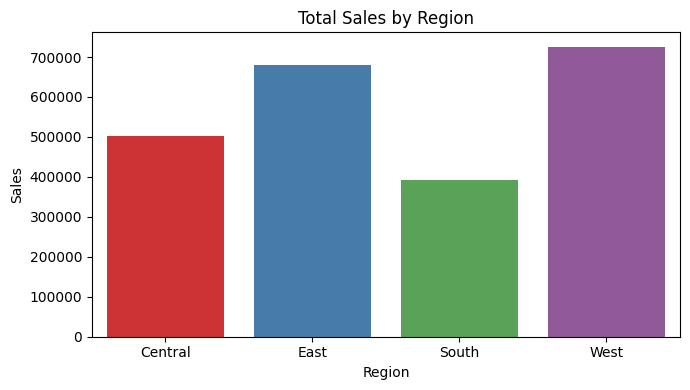

In [82]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
plt.figure(figsize=(7, 4))
sns.barplot(data=region_sales, x='Region', y='Sales', palette='Set1')
plt.title('Total Sales by Region')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()


## **(B)**

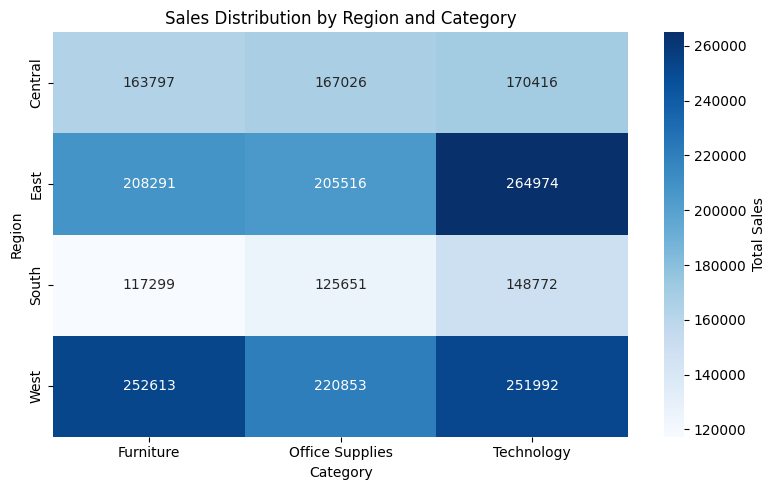

In [78]:
region_cat = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum')
plt.figure(figsize=(8, 5))
sns.heatmap(region_cat, annot=True, fmt=".0f", cmap='Blues', cbar_kws={'label': 'Total Sales'})
plt.title('Sales Distribution by Region and Category')
plt.tight_layout()
plt.show()

## **(C)**

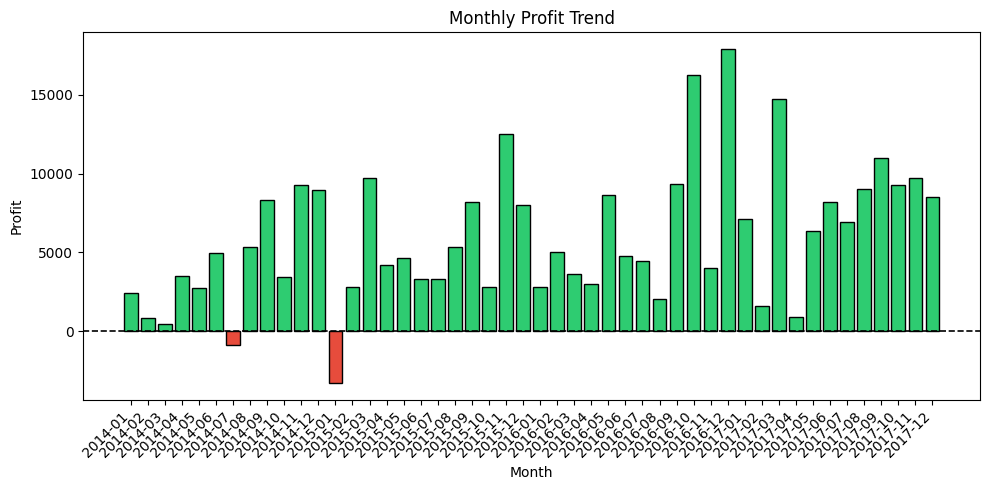

In [112]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_profit = df.resample('ME', on='Order Date')['Profit'].sum().reset_index()
monthly_profit['Month_Str'] = monthly_profit['Order Date'].dt.strftime('%Y-%m')
plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in monthly_profit['Profit']]
plt.bar(monthly_profit['Month_Str'], monthly_profit['Profit'], color=colors, edgecolor='black')
plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Task: **04**
## **(A)**

In [84]:
def get_contrast(rgb1, rgb2):
    def get_luminance(c):
        c = [v / 255.0 for v in c]
        c = [v / 12.92 if v <= 0.04045 else ((v + 0.055) / 1.055) ** 2.4 for v in c]
        return 0.2126 * c[0] + 0.7152 * c[1] + 0.0722 * c[2]
    l1, l2 = get_luminance(rgb1), get_luminance(rgb2)
    return (max(l1, l2) + 0.05) / (min(l1, l2) + 0.05)

white = (255, 255, 255)
colors = {
    "Light Blue": (135, 206, 235),
    "Dark Blue": (31, 119, 180),
    "Yellow": (254, 224, 144),
    "Red": (215, 48, 39),
    "Green": (26, 152, 80)
}
for name, rgb in colors.items():
    ratio = get_contrast(rgb, white)
    status = "FAIL (< 4.5:1)" if ratio < 4.5 else "PASS"
    print(f"{name}: {ratio:.2f}:1 -> {status}")

Light Blue: 1.74:1 -> FAIL (< 4.5:1)
Dark Blue: 4.82:1 -> PASS
Yellow: 1.29:1 -> FAIL (< 4.5:1)
Red: 4.84:1 -> PASS
Green: 3.72:1 -> FAIL (< 4.5:1)


## **(B)**

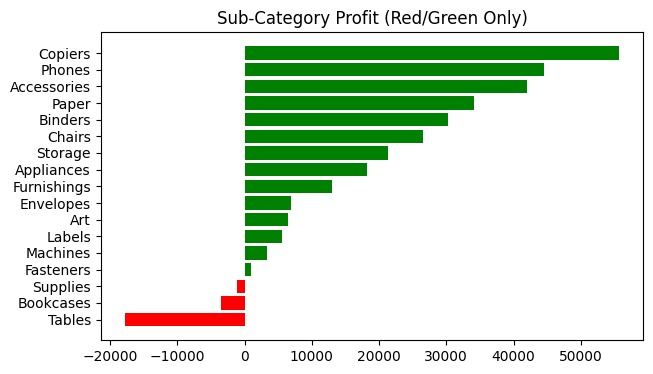

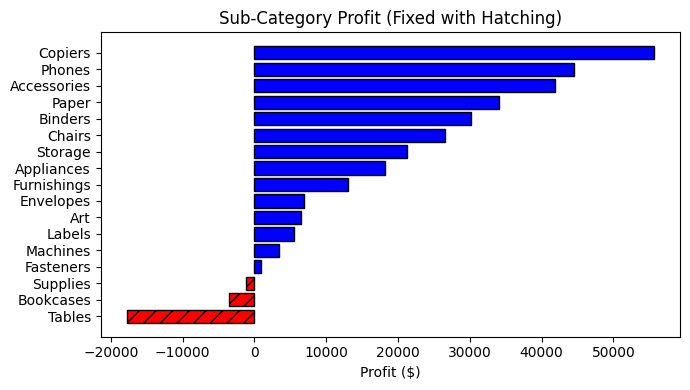

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('superstore.csv', encoding='latin1')
profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(7, 4))
colors = ['red' if p < 0 else 'green' for p in profit]
plt.barh(profit.index, profit.values, color=colors)
plt.title('Sub-Category Profit (Red/Green Only)')
plt.show()

plt.figure(figsize=(7, 4))
for subcat, val in profit.items():
    if val < 0:
        plt.barh(subcat, val, color='red', edgecolor='black', hatch='//')
    else:
        plt.barh(subcat, val, color='blue', edgecolor='black')

plt.title('Sub-Category Profit (Fixed with Hatching)')
plt.xlabel('Profit ($)')
plt.tight_layout()
plt.show()

# Task: **05**

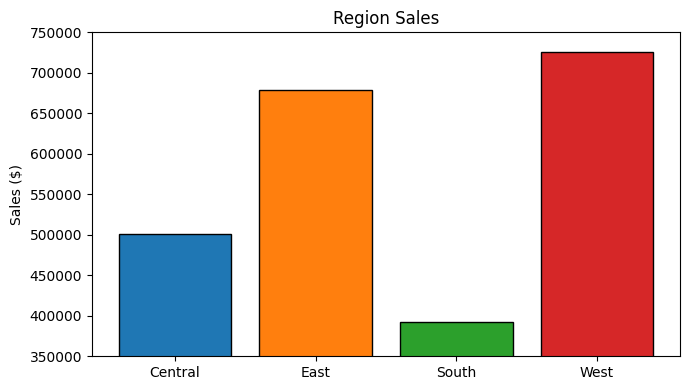

In [107]:
region_sales = df.groupby('Region')['Sales'].sum()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
plt.figure(figsize=(7, 4))
plt.bar(region_sales.index, region_sales.values, color=colors, edgecolor='black')
plt.ylim(350000, 750000)
plt.title('Region Sales')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_791/1712541331.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample('M', on='Order Date')[['Sales', 'Profit']].sum()


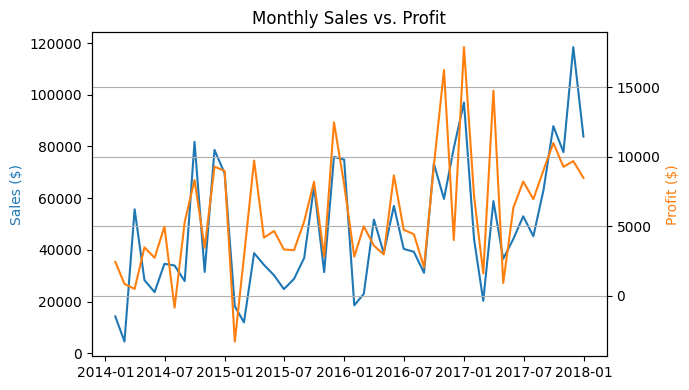

In [98]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly = df.resample('M', on='Order Date')[['Sales', 'Profit']].sum()

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

ax1.plot(monthly.index, monthly['Sales'], color='tab:blue')
ax2.plot(monthly.index, monthly['Profit'], color='tab:orange')

ax1.set_ylabel('Sales ($)', color='tab:blue')
ax2.set_ylabel('Profit ($)', color='tab:orange')
plt.title('Monthly Sales vs. Profit')
plt.tight_layout()
plt.grid()
plt.show()

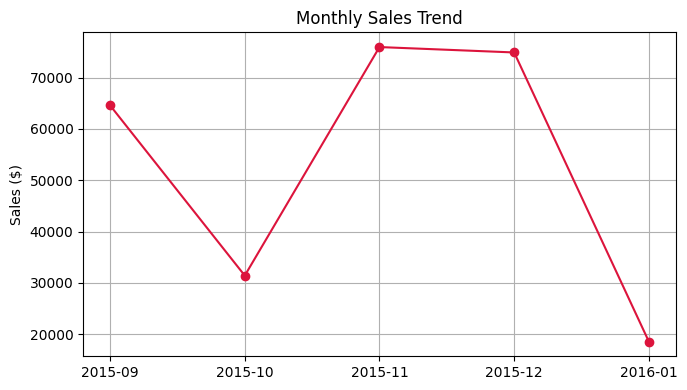

In [97]:
cherry_picked = monthly.loc['2015-09-01':'2016-02-01']

plt.figure(figsize=(7, 4))
plt.plot(cherry_picked.index.strftime('%Y-%m'), cherry_picked['Sales'], marker='o', color='crimson')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.grid()
plt.show()

# Task: **06**

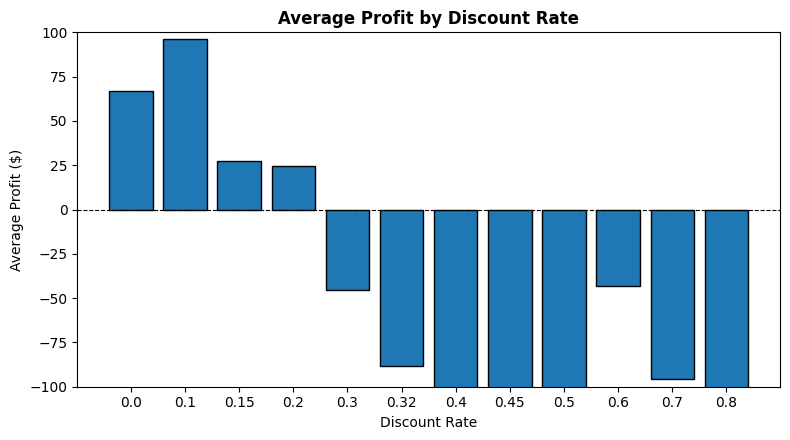

In [113]:
discount_profit = df.groupby('Discount')['Profit'].mean().reset_index()
plt.figure(figsize=(8, 4.5))
plt.bar(discount_profit['Discount'].astype(str), discount_profit['Profit'], color='#1f77b4', edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Average Profit by Discount Rate', fontsize=12, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Average Profit ($)')
plt.ylim(-100, 100)
plt.tight_layout()
plt.show()

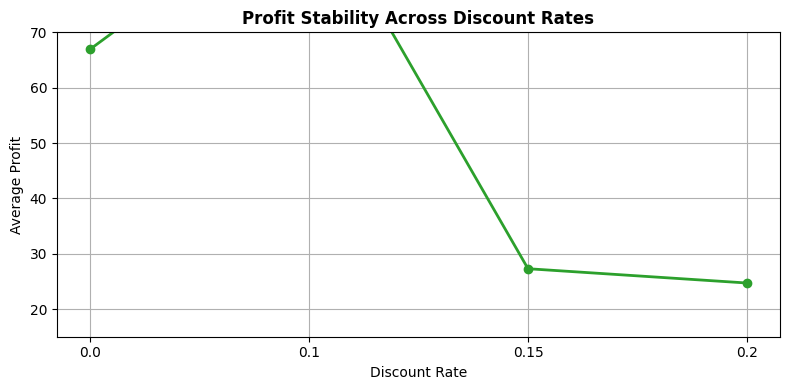

In [114]:
misleading_data = discount_profit[discount_profit['Discount'] <= 0.2]

plt.figure(figsize=(8, 4))
plt.plot(misleading_data['Discount'].astype(str), misleading_data['Profit'], marker='o', color='#2ca02c', linewidth=2)
plt.ylim(15, 70)
plt.title('Profit Stability Across Discount Rates', fontsize=12, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Average Profit')
plt.tight_layout()
plt.grid()
plt.show()